# COSC 520 Assignment 1: Membership Benchmarks

Compare five algorithms from **1,000 to 100,000,000 usernames**. Run all cells to load saved results and display the plots. Set `RUN_NEW_EXPERIMENTS = True` to rerun; large linear-search experiments can take tens of minutes.

Start from the project directory:
```bash
PYTHONHASHSEED=42 uv run jupyter lab notebooks/experiments.ipynb
```
Select the project's Python 3.12 kernel.

## 1. Setup

In [1]:
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
import json
import os

from IPython.display import display, Markdown
%matplotlib inline
from matplotlib import pyplot as plt
from cosc520_assignment1.datasets import load_dataset
from cosc520_assignment1.benchmark import BenchmarkConfig, run_benchmarks, load_results
from cosc520_assignment1.plotting import (
    LABELS, plot_runtimes, plot_storage_sizes, plot_false_positive_rates,
)

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Run from the project or notebooks directory."
plt.rcParams.update({"font.size": 10, "figure.dpi": 110})


def show_and_save(figure, name):
    for extension in ("png", "pdf"):
        figure.savefig(FIGURE_DIR / f"{name}.{extension}", dpi=180, bbox_inches="tight")
    display(figure)
    plt.close(figure)

## 2. Configuration

The bundled `data/hundred-million/` contains 100,000,000 unique 7-character usernames, plus 10,000 known-present and 10,000 known-absent queries. The insertion file is about 800 MB. Access them through `dataset.logins`, `dataset.hits`, and `dataset.misses` below.

Each algorithm uses 3 repetitions and 1,000 queries per category. At most 2 processes run together; memory-heavy jobs may run alone. Smaller experiments use insertion prefixes and matching queries. Set `RUN_NEW_EXPERIMENTS = True` to run with the bundled data. Saved plots retain the previous measurements and their original query sets.

In [2]:
RUN_NEW_EXPERIMENTS = False
DATA_DIR = ROOT / "data" / "hundred-million"
EXISTING_RUN = ROOT / "results" / "run-20261003T012703695555Z"

CONFIG = BenchmarkConfig(
    sizes=(1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000),
    repeats=3, workers=2, queries_per_kind=1_000,
    warmup_queries=100, query_batch_size=64,
    seed=42, login_length=7,
    cuckoo_fingerprint_bits=8, cuckoo_target_load=0.90,
    memory_budget_bytes=12 * 1024**3,
)
CONFIG.validate()

dataset = load_dataset(DATA_DIR)
assert max(CONFIG.sizes) <= len(dataset.logins), "The bundled dataset is too small."
print(f"Bundled input: {len(dataset.logins):,} usernames")
print(f"Query files: {len(dataset.hits):,} known-present, {len(dataset.misses):,} known-absent")

Bundled input: 100,000,000 usernames
Query files: 10,000 known-present, 10,000 known-absent


## 3. Run or load results

In [3]:
if RUN_NEW_EXPERIMENTS:
    assert os.environ.get("PYTHONHASHSEED") == "42", "Restart Jupyter with PYTHONHASHSEED=42."
    OUTPUT_DIR = ROOT / "results" / datetime.now(timezone.utc).strftime("notebook-%Y%m%dT%H%M%S%fZ")
    progress = display("Starting experiments...", display_id=True)
    records = run_benchmarks(
        CONFIG, data_dir=DATA_DIR, output_dir=OUTPUT_DIR,
        progress=lambda message: progress.update(message),
    )
    progress.update("Experiments finished; see status below.")
else:
    OUTPUT_DIR = EXISTING_RUN
    assert not (OUTPUT_DIR / ".incomplete").exists(), "This run is still in progress."
    records = load_results(OUTPUT_DIR / "raw.csv")

metadata = json.loads((OUTPUT_DIR / "environment.json").read_text())
actual = metadata["config"]
print("Results:", OUTPUT_DIR.relative_to(ROOT))
print("Input sizes:", ", ".join(f"{n:,}" for n in actual["sizes"]))
print(f"Repetitions: {actual['repeats']} | Queries/category: {actual['queries_per_kind']:,}")
print(f"Worker limit: {actual['workers']} | Worker PIDs: {metadata.get('worker_pids', [])}")
print("Record status:", dict(Counter(record.status for record in records)))
failures = sorted({(r.algorithm, r.n, r.error) for r in records if r.status != "ok"})
if failures:
    rows = ["| Algorithm | n | Failure / skip reason |", "|---|---:|---|"]
    rows += [f"| {LABELS[a]} | {n:,} | {error.replace('|', '/')} |" for a, n, error in failures[:10]]
    display(Markdown("\n".join(rows)))
    print("Full diagnostics: raw.csv")

FIGURE_DIR = OUTPUT_DIR / "figures-notebook"
FIGURE_DIR.mkdir(exist_ok=True)

Results: results/run-20261003T012703695555Z
Input sizes: 1,000, 10,000, 100,000, 1,000,000, 10,000,000, 100,000,000
Repetitions: 3 | Queries/category: 1,000
Worker limit: 2 | Worker PIDs: [6012, 6013]
Record status: {'ok': 270}


## 4. Runtime

Lines show medians; bands show interquartile ranges across repetitions. Build includes input loading. Search excludes setup and warmup; categories follow true membership, including filter false positives.

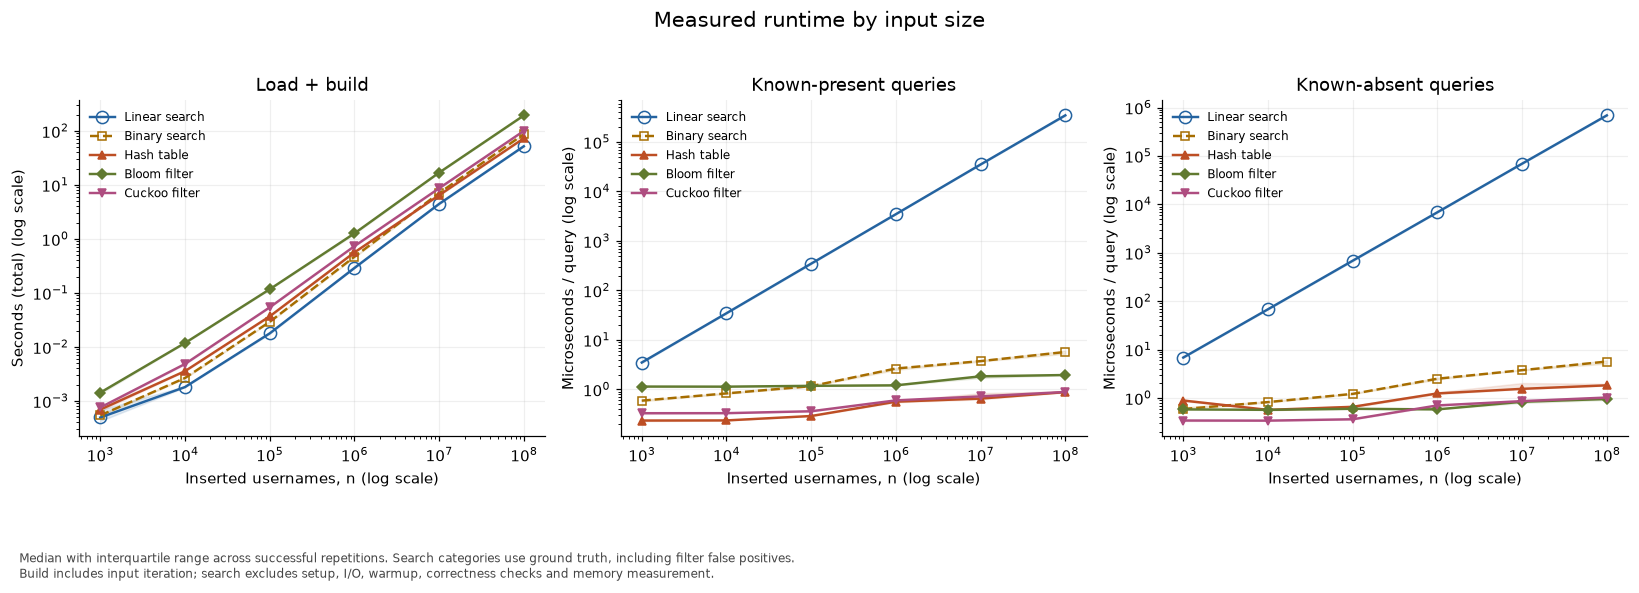

In [4]:
show_and_save(plot_runtimes(records), "runtimes")

## 5. Storage after insertion

Retained Python objects, including stored strings and containers; excludes the input dataset and process overhead. This is not peak RAM.

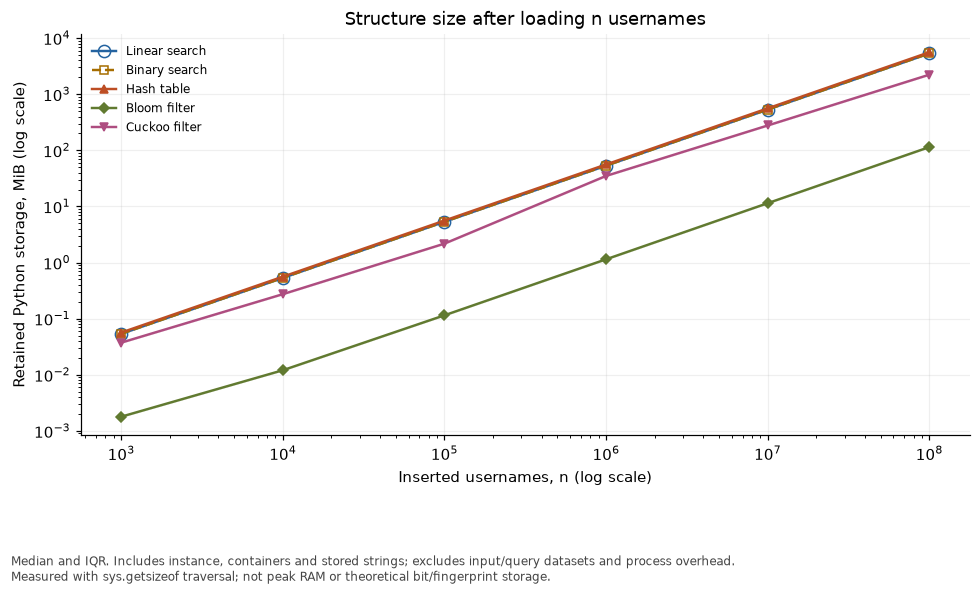

In [5]:
show_and_save(plot_storage_sizes(records), "storage")

## 6. Observed false-positive rate

False positives divided by known-absent queries. All figures are also saved as PNG and PDF beside the CSV results.

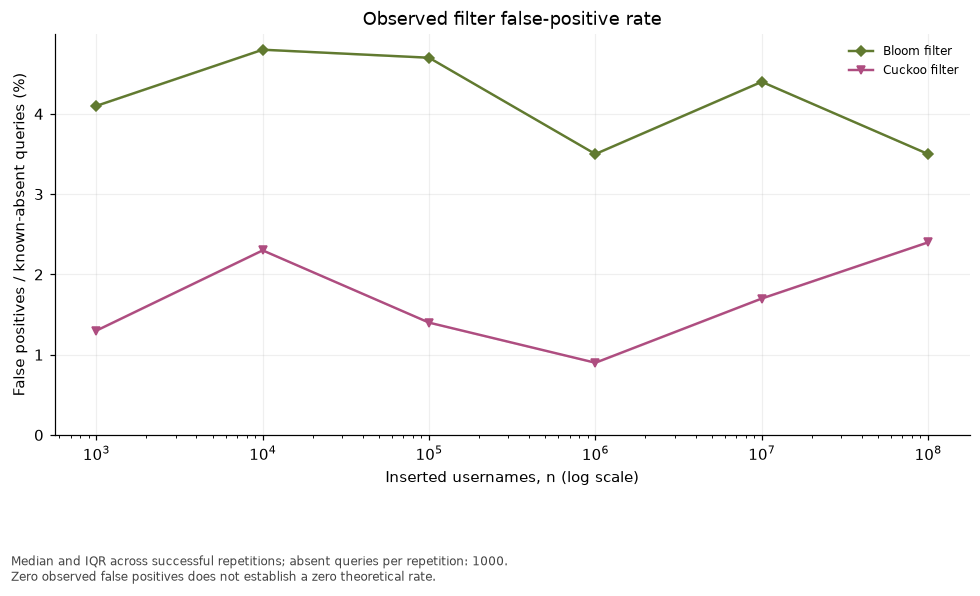

In [6]:
show_and_save(plot_false_positive_rates(records), "false-positive-rates")